# SkinLesions Demo Notebook

This notebook demonstrates loading a trained checkpoint and running inference on test samples.

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import torch
import yaml
from torch.utils.data import DataLoader

# Ensure local package imports work when notebook is opened from either repo root or notebooks/.
cwd = Path.cwd().resolve()
repo_candidates = [cwd, cwd.parent]
for candidate in repo_candidates:
    if (candidate / 'skinlesions').exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

from skinlesions.models import build_model
from skinlesions.data.dataset import SkinLesionDataset
from skinlesions import transforms as T

In [3]:
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CFG_PATH = REPO_ROOT / 'configs' / 'config.yaml'

with CFG_PATH.open('r', encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

classes = cfg['data']['classes']
split_dir = REPO_ROOT / cfg['paths'].get('split_manifest_dir', 'results/logs/splits')
model_dir = REPO_ROOT / cfg['paths'].get('model_dir', 'results/models')

print('Repo root:', REPO_ROOT)
print('Split dir:', split_dir)
print('Model dir:', model_dir)

Repo root: /blue/bme6938/d.tan/BME6938-Spring-2026-Project-2-Group-3
Split dir: /blue/bme6938/d.tan/BME6938-Spring-2026-Project-2-Group-3/results/logs/splits
Model dir: /blue/bme6938/d.tan/BME6938-Spring-2026-Project-2-Group-3/results/models


In [4]:
checkpoints = sorted(model_dir.glob('best_*.pt'))
if not checkpoints:
    raise FileNotFoundError(f'No best_*.pt checkpoints found in {model_dir}')

ckpt_path = checkpoints[-1]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ckpt = torch.load(ckpt_path, map_location=device)

model_name = ckpt.get('model_name', cfg['training']['model_name'])
ckpt_classes = ckpt.get('classes', classes)

model = build_model(model_name=model_name, num_classes=len(ckpt_classes))
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)
model.eval()

print('Using checkpoint:', ckpt_path.name)
print('Model:', model_name)
print('Device:', device)

Using checkpoint: best_resnet50_pretrained_resnet50_run.pt
Model: resnet50_pretrained
Device: cuda


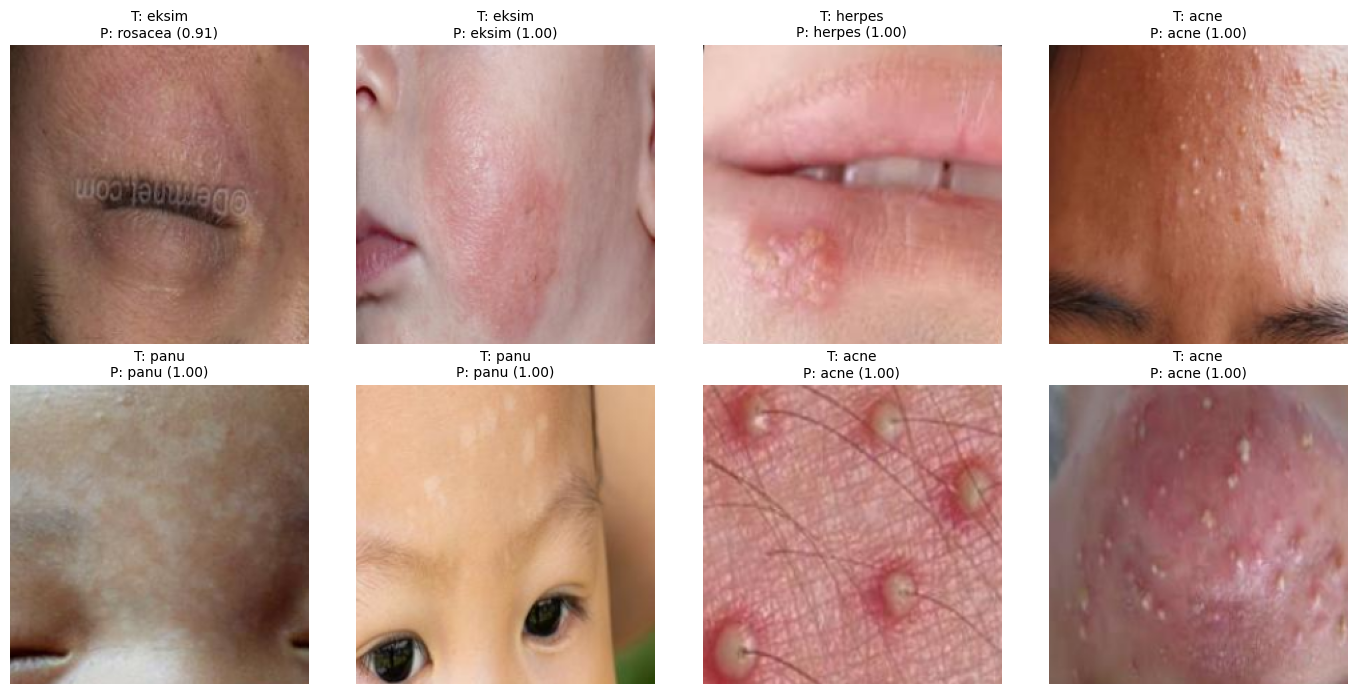

In [5]:
class_to_idx = {c: i for i, c in enumerate(ckpt_classes)}
test_manifest = split_dir / 'test.csv'

dataset = SkinLesionDataset(
    manifest_path=test_manifest,
    class_to_idx=class_to_idx,
    transform=T.from_config(cfg, split='test'),
)

loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)
images, labels = next(iter(loader))

with torch.no_grad():
    logits = model(images.to(device))
    probs = torch.softmax(logits, dim=1).cpu()
    preds = probs.argmax(dim=1)

idx_to_class = {v: k for k, v in class_to_idx.items()}

def denormalize(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img_tensor.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(min(8, len(images))):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    true_cls = idx_to_class[int(labels[i])]
    pred_cls = idx_to_class[int(preds[i])]
    conf = float(probs[i, int(preds[i])])

    axes[i].imshow(img)
    axes[i].set_title(f'T: {true_cls}\nP: {pred_cls} ({conf:.2f})', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [6]:
metrics_candidates = sorted((REPO_ROOT / 'results' / 'logs').glob('metrics_*.json'))
if metrics_candidates:
    with metrics_candidates[-1].open('r', encoding='utf-8') as f:
        metrics = json.load(f)
    print('Loaded metrics:', metrics_candidates[-1].name)
    for key in ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc_macro']:
        if key in metrics:
            print(f'{key}: {metrics[key]}')
else:
    print('No metrics_*.json files found yet in results/logs.')

Loaded metrics: metrics_best_resnet50_pretrained_resnet50_run.json
accuracy: 0.968609865470852
f1_macro: 0.9684560375858201
f1_weighted: 0.9684859905769952
roc_auc_macro: 0.9989643849200688
